# Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Ridge


import src.conformal_prediction as cp
import src.metrics as met
from src.model_tuning import TimeSeriesRidgeTuner

# Define toy data

In [ ]:
# Define simple timeseries of a year with one target and three covariates. Target is a linear combination of the covariates with some noise.
N = np.arange(0, 8760)
X1 = np.sin(2 * np.pi * N / 8760)
X2 = np.cos(2 * np.pi * N / 720)
X3 = np.sin(2 * np.pi * N / 168)

random_steps = np.random.normal(0, 0.1, size=len(N))
X4 = np.cumsum(random_steps)

index = pd.date_range(start='2020-01-01', periods=len(N), freq='h')
X = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4}, index=index)
Y = 2 * X1 + 3 * X2 + 4 * X3 + 5 * X4 + np.random.normal(0, 1, len(X1))

# Add small hidden trend to the target variable
Y += 0.001 * N

# Add small hidden variation to the target variable
Y +=  np.sin(2 * np.pi * N / 2000)

Y = pd.Series(Y, index=index, name='Y')

# Add meaningless covariates to the dataset
X['X5'] = np.random.normal(0, 1, len(X1))
X['X6'] = np.random.normal(0, 1, len(X1))
X['X7'] = np.random.normal(0, 1, len(X1))


X_train, X_cal, X_test, y_train, y_cal, y_test, x_scaler, y_scaler = cp.train_cal_test_date_split(X, Y, train_end = '2020-09-30', calibration_end = '2020-10-31', test_end = '2020-12-31', scaled=True)

penalty_grid = np.logspace(-4, 4, 50)
ts_ridge_tuner = TimeSeriesRidgeTuner(X_train, y_train, penalty_grid, val_share = 0.2)
selected_features, best_candidate_alpha, best_candidate_mse = ts_ridge_tuner.forward_selection()

print("### Model Tuning Results ###")
print(f"Selected features: {selected_features}")
print(f"Best candidate alpha: {best_candidate_alpha}")

X_train = X_train[selected_features]
X_cal = X_cal[selected_features]
X_test = X_test[selected_features]

model = Ridge(alpha=best_candidate_alpha)
model.fit(X_train, y_train)
cal_pred = model.predict(X_cal)
test_pred = model.predict(X_test)

# Plot data
fig, ax = plt.subplots(5, 1, figsize=(16, 8), sharex=True)

for i in range(5):
    if i == 0:
        Y.plot(ax=ax[i], color='blue', label='Target')
    else:
        X.iloc[:, i-1].plot(ax=ax[i], color='orange', label=f'Covariate {i}')
    
plt.show()

NameError: name 'np' is not defined

# Classic conformal prediction

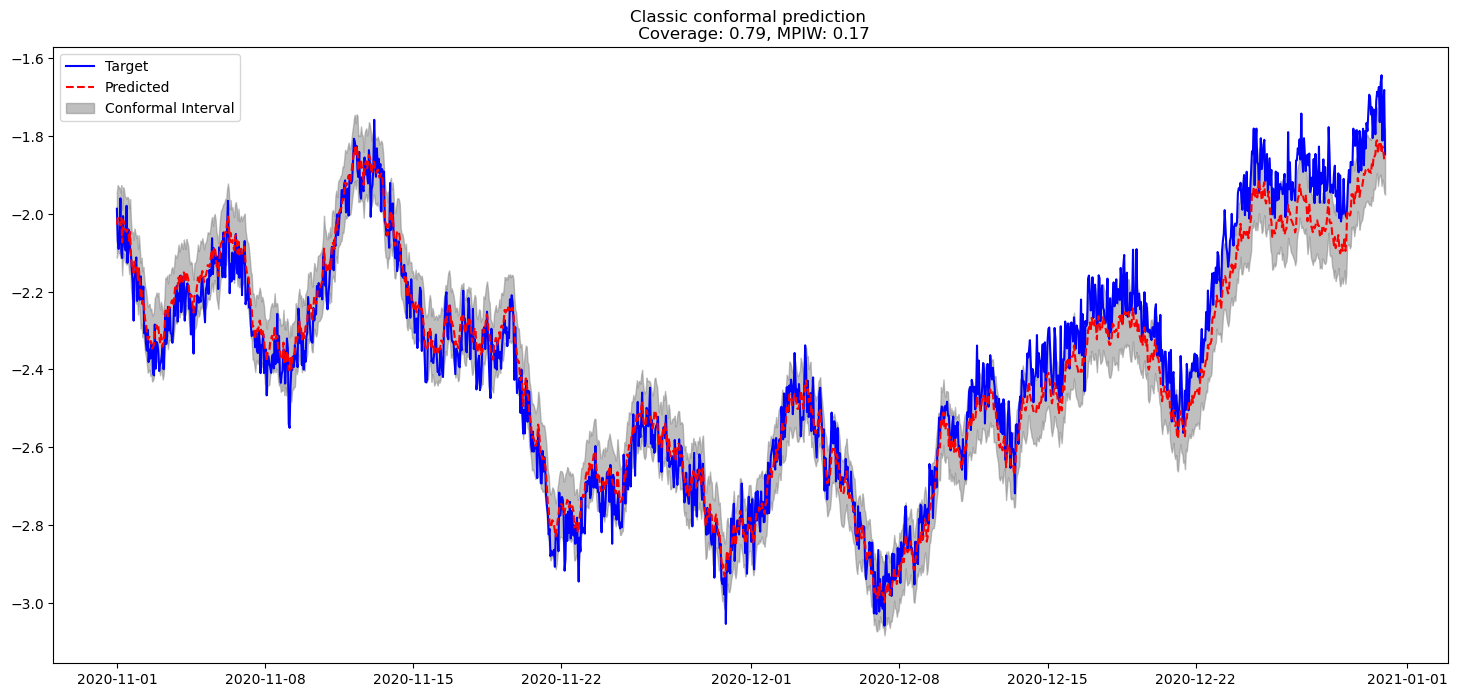

In [ ]:
classic_cp = cp.ConformalPredictor()
classic_cp.fit(y_cal = y_cal,  y_pred = cal_pred, alpha = 0.1)
lower, upper = classic_cp.conformalize(y_pred_test = test_pred)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'Classic conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.plot(y_test.index, test_pred, color='red', linestyle='--', label='Predicted')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()


# Quantile conformal prediction for a single interval

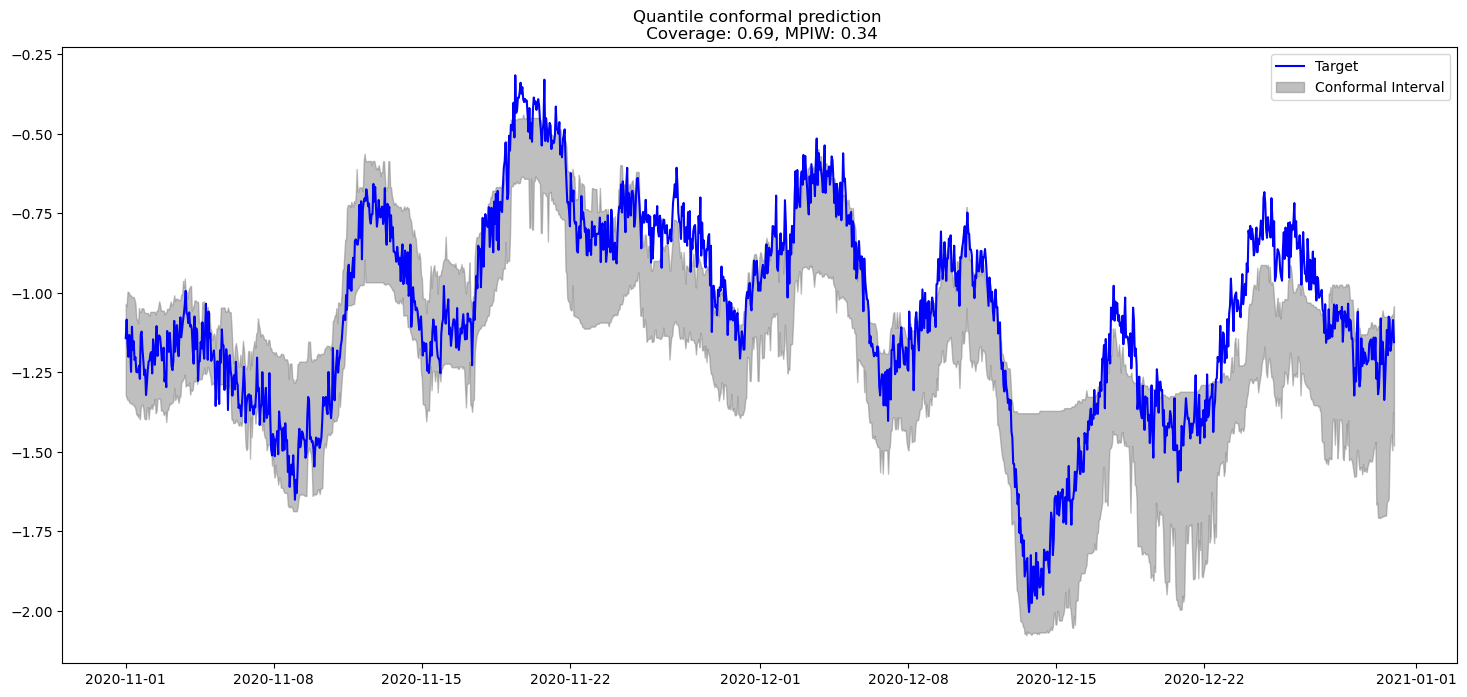

In [ ]:
# Define a quantile regressor and fit it to the calibration data. Then use it to generate conformal prediction intervals for the test data.
from sklearn.ensemble import GradientBoostingRegressor
quantile_regressor_lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
quantile_regressor_upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
quantile_regressor_lower.fit(X_train, y_train)
quantile_regressor_upper.fit(X_train, y_train)

lower_pred_cal = quantile_regressor_lower.predict(X_cal)
upper_pred_cal = quantile_regressor_upper.predict(X_cal)

lower_pred = quantile_regressor_lower.predict(X_test)
upper_pred = quantile_regressor_upper.predict(X_test)



quantile_cp = cp.QuantileConformalPredictor()
quantile_cp.fit(y_cal = y_cal,  y_lower = lower_pred_cal, y_upper = upper_pred_cal, alpha = 0.1)
lower, upper = quantile_cp.conformalize(y_lower_test = lower_pred, y_upper_test = upper_pred)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'Quantile conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()

# Bayesian conformal prediction for a probabilistic regressor

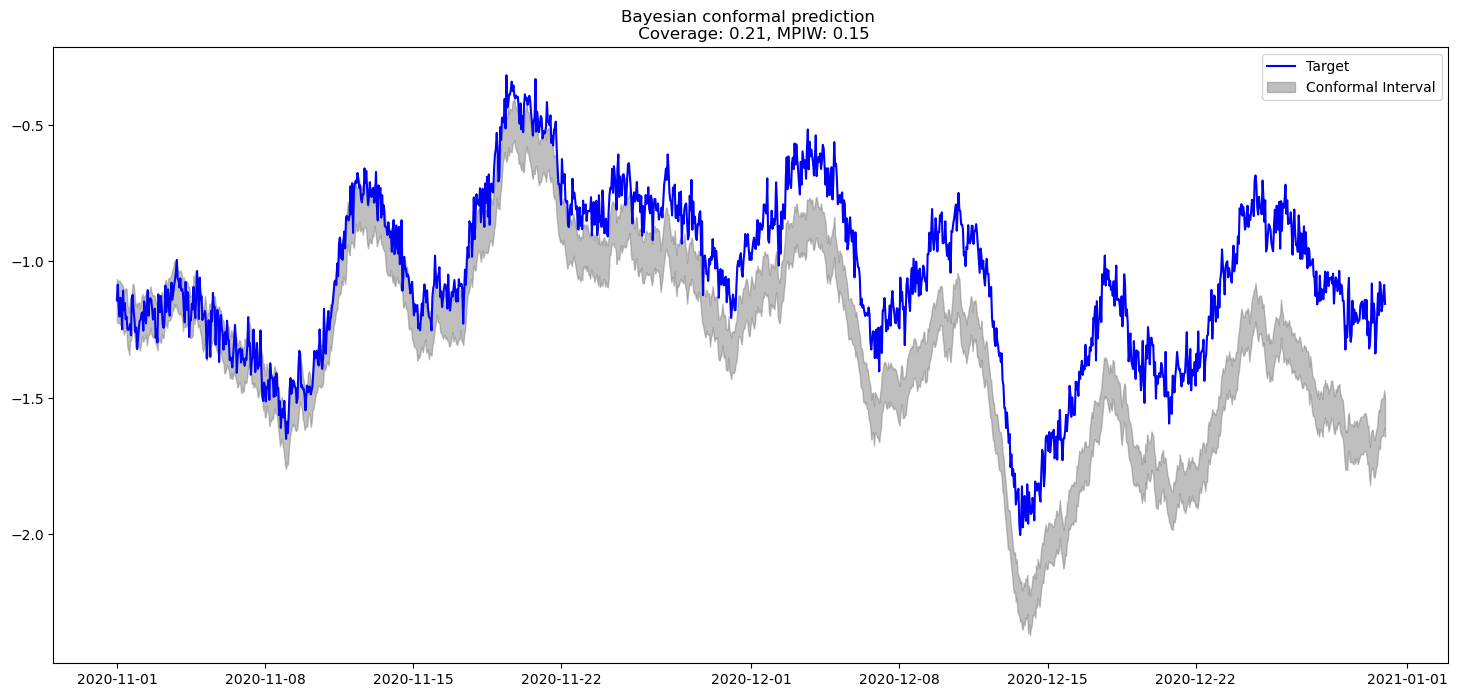

In [ ]:
# Fit a simple Bayesian model to the calibration data and use it to generate conformal prediction intervals for the test data.
from sklearn.linear_model import BayesianRidge
bayesian_model = BayesianRidge()
bayesian_model.fit(X_cal, y_cal)

bayesian_pred_cal = bayesian_model.predict(X_cal, return_std=True)
bayesian_pred = bayesian_model.predict(X_test, return_std=True)

bayesian_cp = cp.BayesianConformalPredictor()
bayesian_cp.fit(y_cal = y_cal, mu = bayesian_pred_cal[0], sigma = bayesian_pred_cal[1], alpha = 0.1)
bayesian_lower, bayesian_upper = bayesian_cp.conformalize(mu_test = bayesian_pred[0], sigma_test = bayesian_pred[1])

cov = met.PICP(y_test, bayesian_lower, bayesian_upper)
mpiw = met.MPIW(y_test, bayesian_lower, bayesian_upper)

plt.figure(figsize=(18, 8))
plt.title(f'Bayesian conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, bayesian_lower, bayesian_upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()

# Conformal predictive system with a linear model

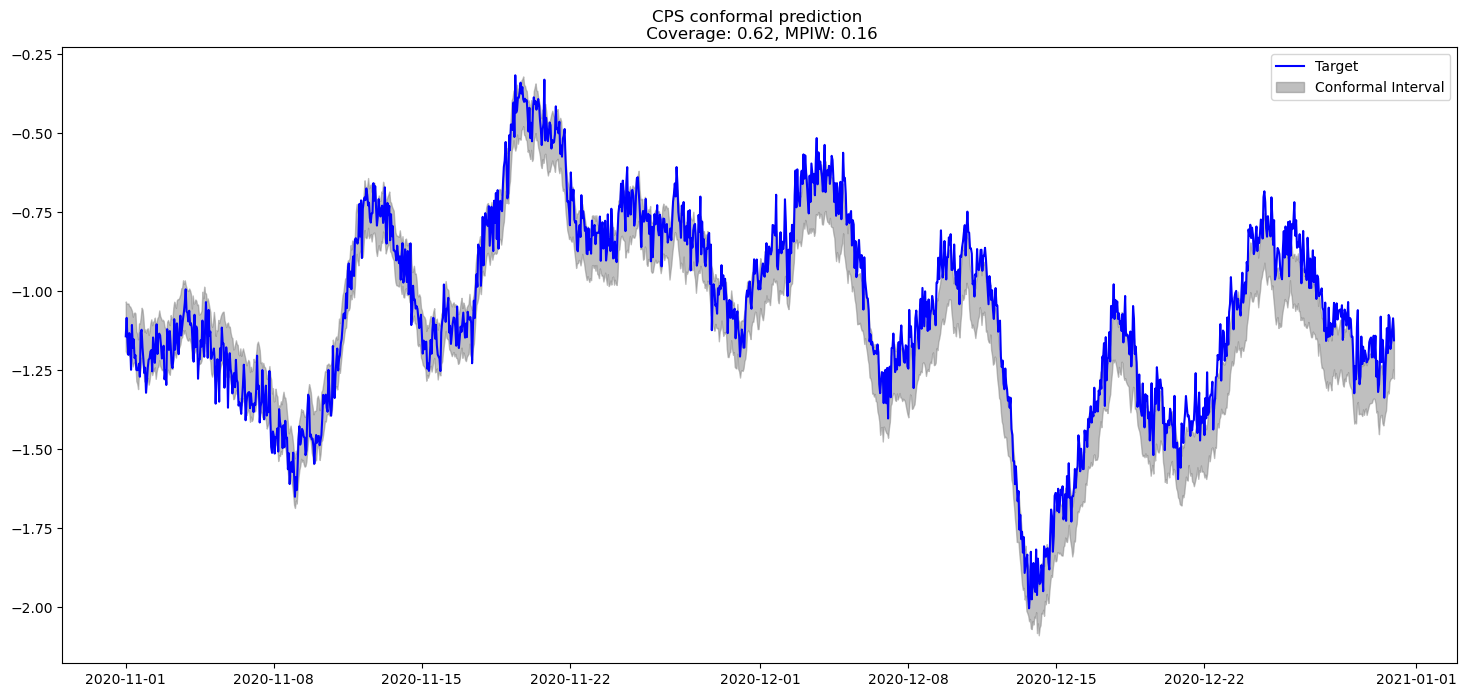

In [ ]:
cps = cp.CPS(model)
cps.fit(X_train, y_train, difficulty_model=None)
cps.calibrate(X_calibration = X_cal, y_calibration = y_cal, bins = 8, mondrian_strategy = None)
cdfs = cps.predict_cpds(X_test)

lower, upper = np.nanquantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()    
plt.show()

# Conformal predictive system with a linear model and KNN difficulty estimator

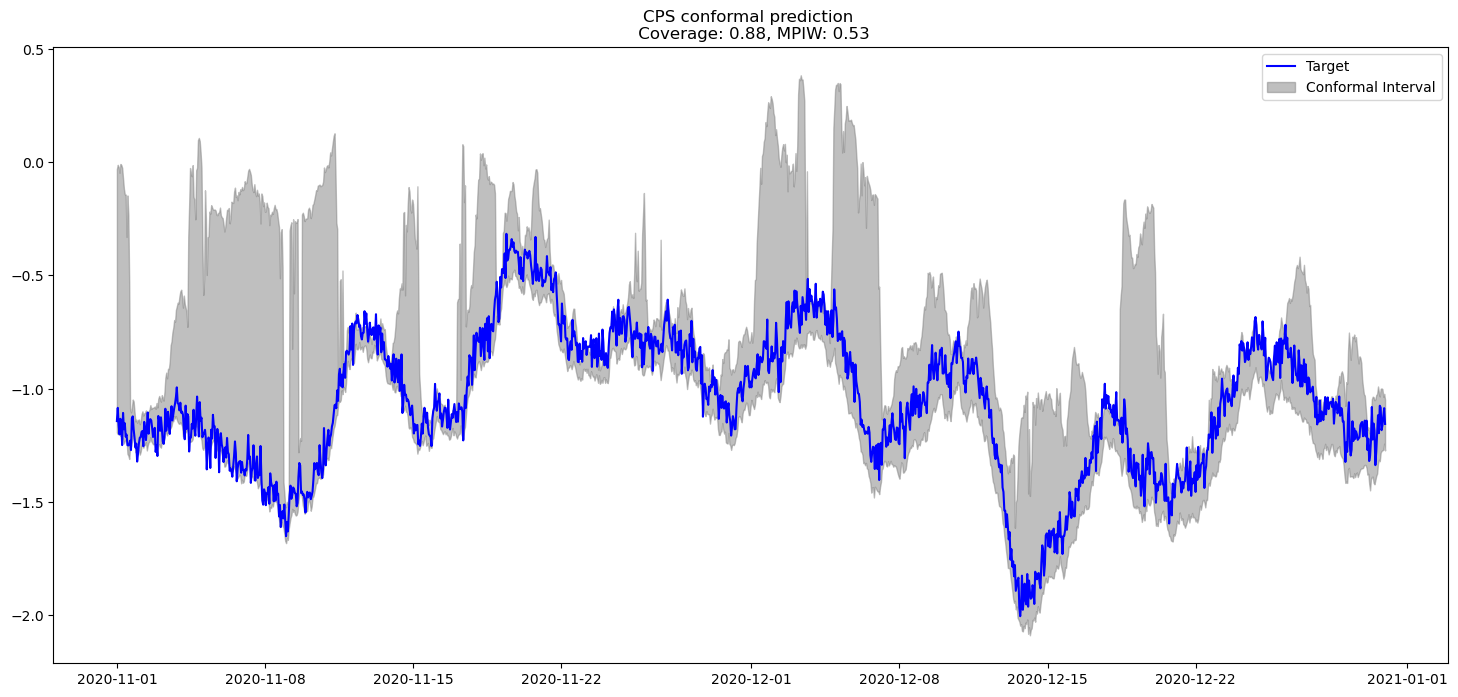

In [ ]:
cps = cp.CPS(model)

cps.fit(X_train, y_train, difficulty_model='knn', k=25)
cps.calibrate(X_calibration = X_cal, y_calibration = y_cal, bins = 8, mondrian_strategy = None)
cdfs = cps.predict_cpds(X_test)

lower, upper = np.nanquantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()    
plt.show()

# Conformal predictive system with a linear model with a KNN difficulty estimator and Mondrian binning on the difficulty

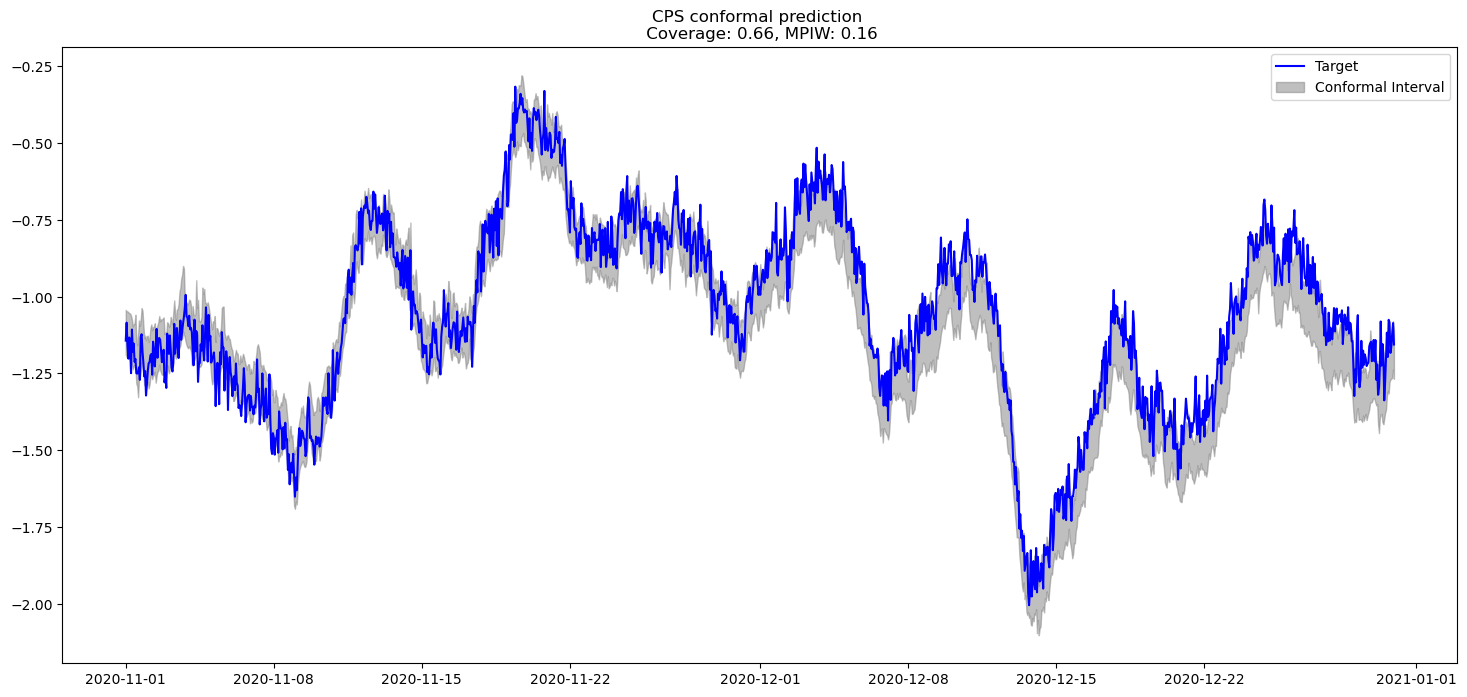

In [ ]:
cps = cp.CPS(model)

cps.fit(X_train, y_train, difficulty_model='knn', k=25)
cps.calibrate(X_calibration = X_cal, y_calibration = y_cal, bins = 8, mondrian_strategy = "difficulty")
cdfs = cps.predict_cpds(X_test)

lower, upper = np.nanquantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()    
plt.show()

# Conformal predictive system with a linear model with a KNN difficulty estimator and Mondrian binning on the predicted level

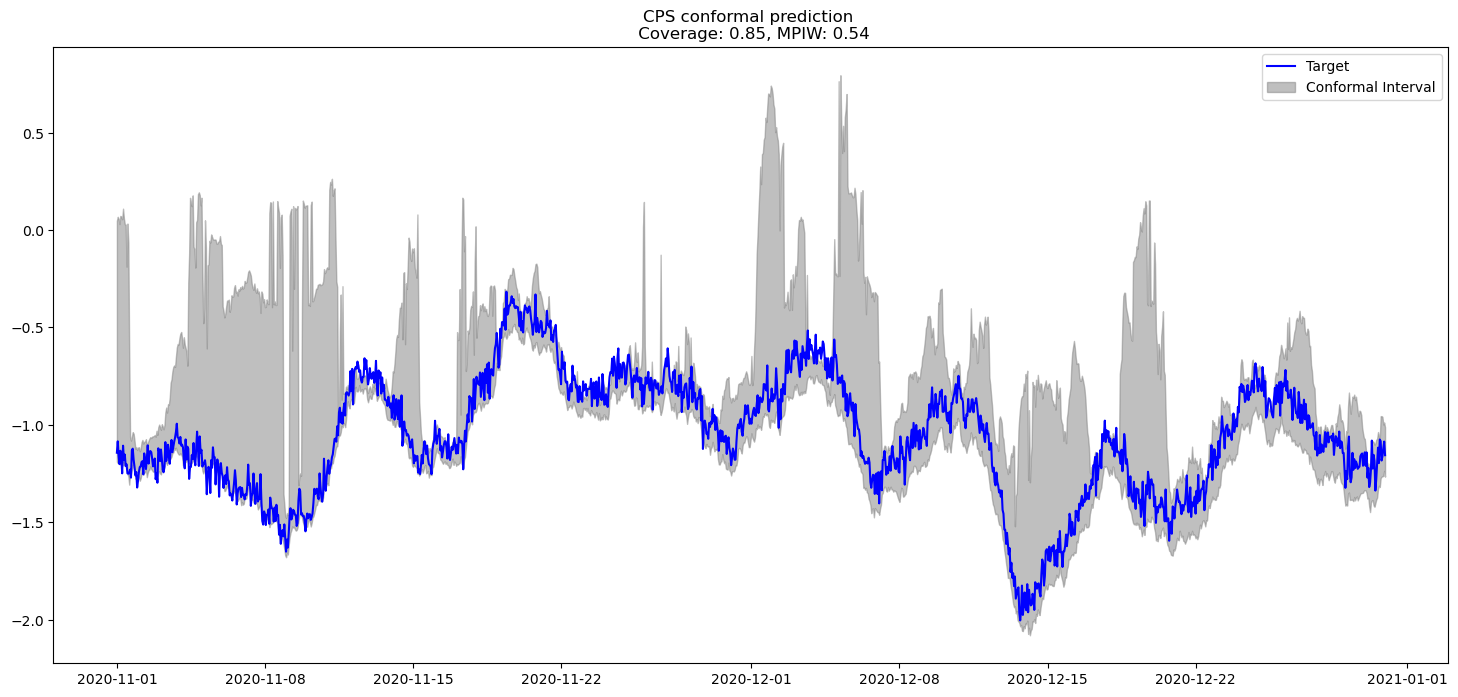

In [ ]:
cps = cp.CPS(model)


cps.fit(X_train, y_train, difficulty_model='knn', k=25)
cps.calibrate(X_calibration = X_cal, y_calibration = y_cal, bins = 8, mondrian_strategy = "predictions")
cdfs = cps.predict_cpds(X_test)

lower, upper = np.quantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()    
plt.show()

# Conformal predictive system with a linear model with a random forest difficulty estimator and Mondrian binning on the difficulty

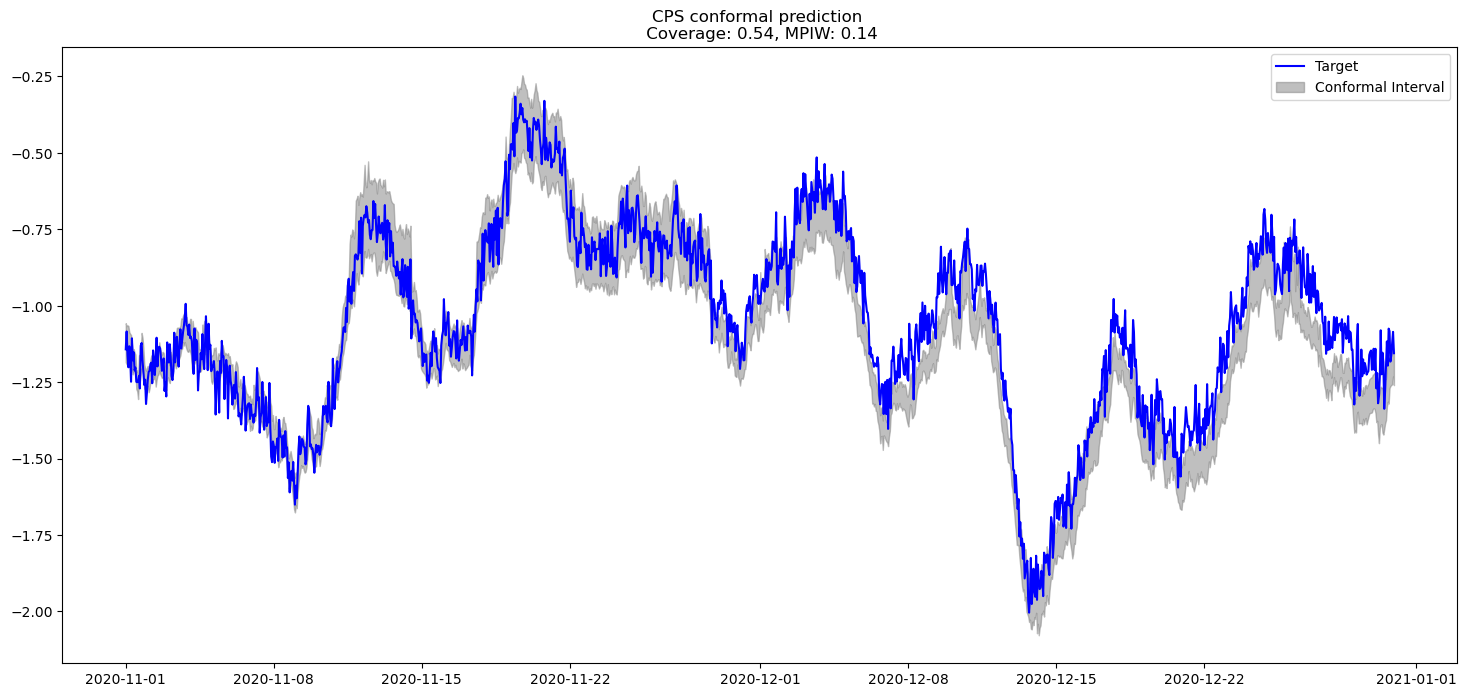

In [ ]:
cps = cp.CPS(model)


cps.fit(X_train, y_train, difficulty_model='rf', k=25)
cps.calibrate(X_calibration = X_cal, y_calibration = y_cal, bins = 8, mondrian_strategy = "predictions")
cdfs = cps.predict_cpds(X_test)

lower, upper = np.quantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()    
plt.show()

# Conformal predictive system with a linear model with a KNN difficulty estimator and martingale drift detector for recalibration

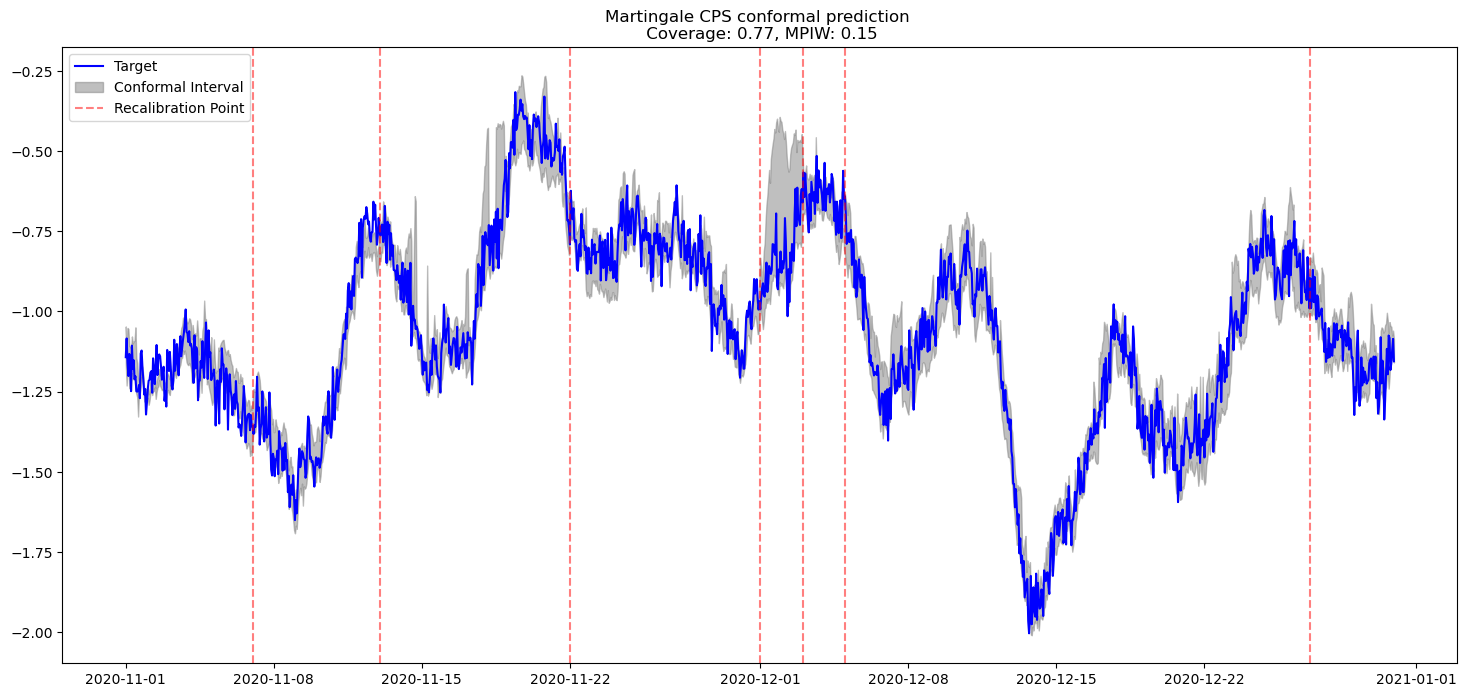

In [ ]:
martingale_cps = cp.MartingaleCPS(model)

martingale_cps.fit(X_train, y_train, difficulty_model='knn', k=25)

cdfs, recalibration_points = martingale_cps.predict_online(X_test, y_test, X_cal, y_cal, window_size = 100, thres = 100, batch_size = 24)
recalibration_points = np.cumsum(recalibration_points)  # Convert to cumulative sum to get the actual indices of recalibration points
lower, upper = np.nanquantile(cdfs, [0.05, 0.95], axis=1)

cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'Martingale CPS conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')

add_label = True
for point in recalibration_points:
    plt.axvline(x=y_test.index[point], color='red', linestyle='--', alpha=0.5, label='Recalibration Point' if add_label else None)
    add_label = False
plt.legend()
plt.show()

# Interpolated quantile conformal prediction for conformalizing a full distribution

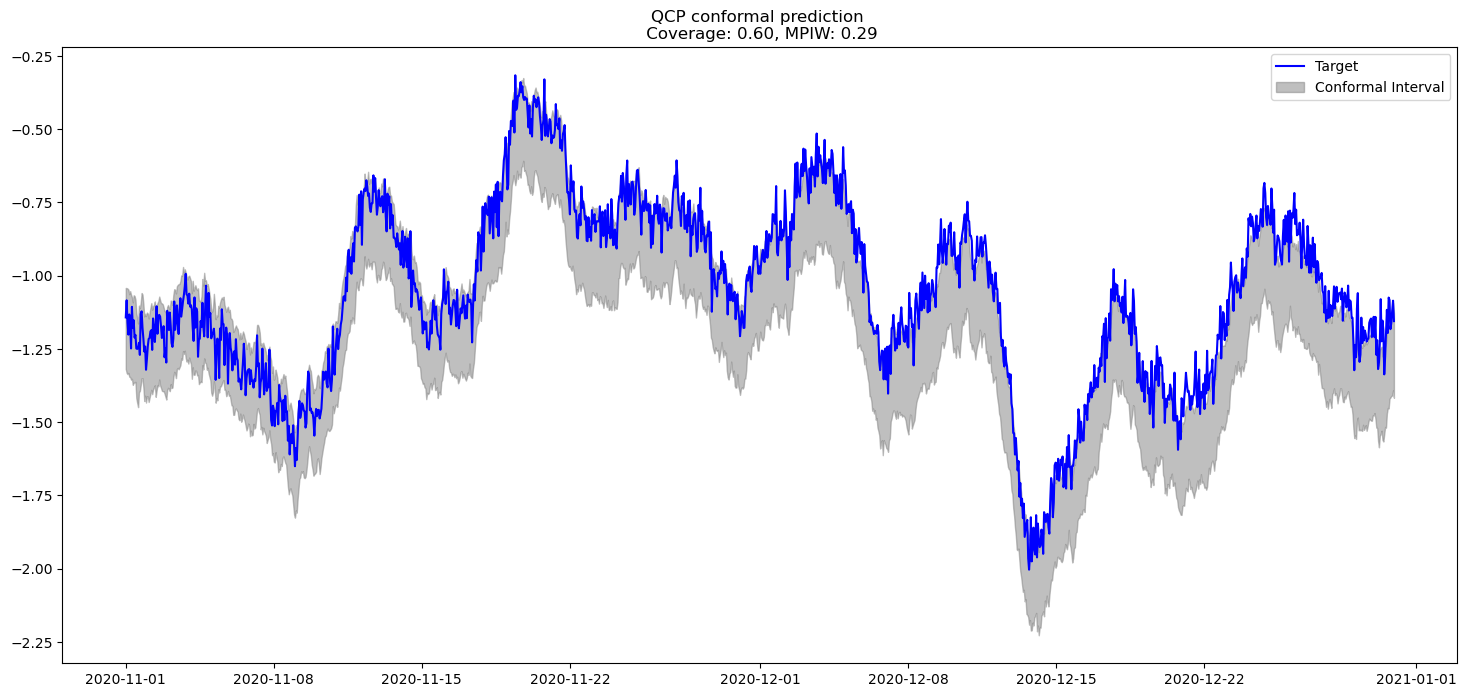

In [ ]:
prob_model = BayesianRidge()

prob_model.fit(X_train, y_train)
cal_mean, cal_std = prob_model.predict(X_cal, return_std=True)
cal_samples = np.random.normal(cal_mean[:, np.newaxis], cal_std.values[:, np.newaxis], size=(len(cal_mean), 1000))

test_mean, test_std = prob_model.predict(X_test, return_std=True)
test_samples = np.random.normal(test_mean[:, np.newaxis], test_std.values[:, np.newaxis], size=(len(test_mean), 1000))

qcp = cp.QCP()
alphas = np.linspace(0.01, 0.99, 10)
qcp.calibrate(X_cal = X_cal, y_cal = y_cal, preds_cal = cal_samples, alphas = alphas)
interpolators = qcp.predict(X_val = X_test, preds_val = test_samples)


eval = np.array([0.05, 0.95])
lower, upper = np.zeros_like(y_test), np.zeros_like(y_test)
for i, interpolator in enumerate(interpolators):
    lower[i], upper[i] = interpolator(eval)
cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'QCP conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()

# Interpolated quantile conformal prediction for conformalizing a full distribution with additional flexibility

c:\Users\jacob\miniconda3\envs\thesis\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\jacob\miniconda3\envs\thesis\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


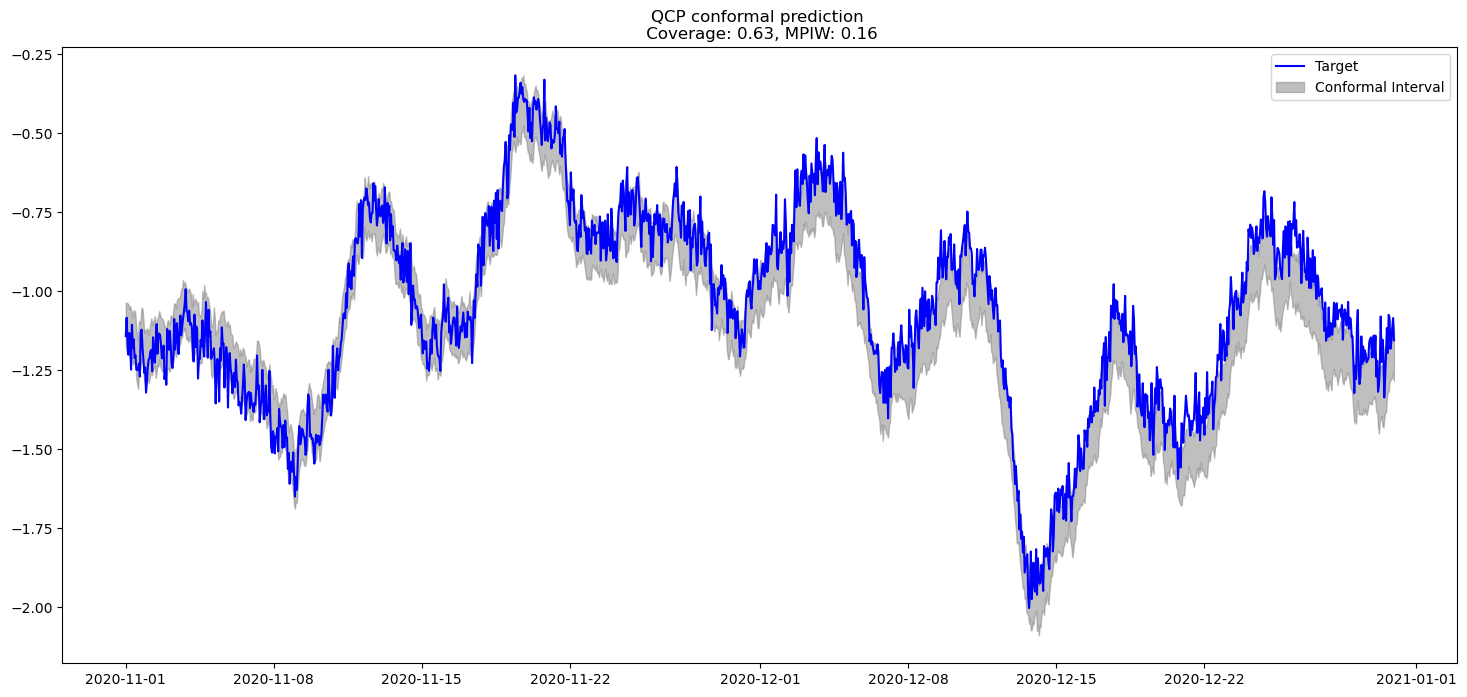

In [ ]:

qcp = cp.QCP(use_clustering = True, clustering_method = "kmeans", n_clusters = 5, asymmetric = True, weighted = True, blend_clusters = True)
alphas = np.linspace(0.01, 0.99, 10)
qcp.calibrate(X_cal = X_cal, y_cal = y_cal, preds_cal = cal_samples, alphas = alphas, X_val = X_test)
interpolators = qcp.predict(X_val = X_test, preds_val = test_samples)


eval = np.array([0.05, 0.95])
lower, upper = np.zeros_like(y_test), np.zeros_like(y_test)
for i, interpolator in enumerate(interpolators):
    lower[i], upper[i] = interpolator(eval)
cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'QCP conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()

# Conformal predictive distribution for conformalizing a full distribution

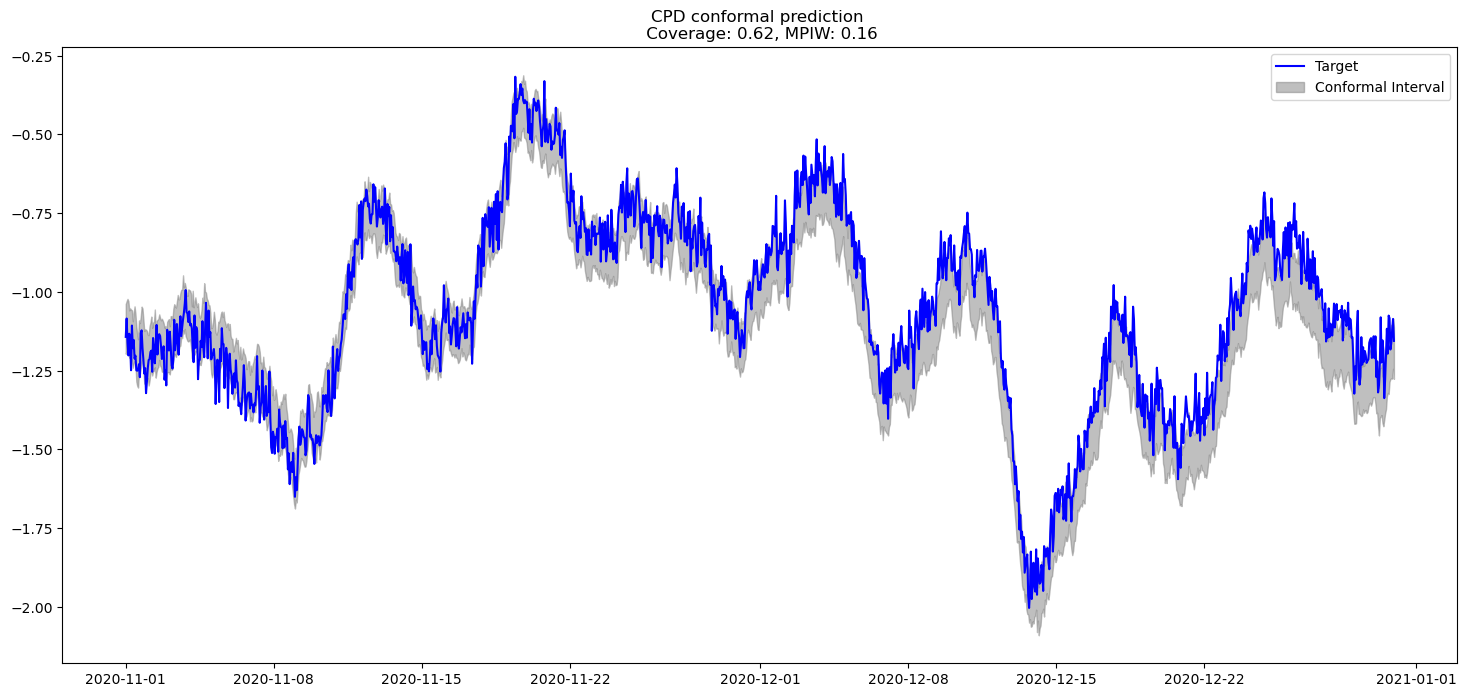

In [ ]:
cpd = cp.CPD()

y_eval = np.linspace(-10, 1, 1000)

cpd.calibrate(X_cal = X_cal, y_cal = y_cal, preds_cal = cal_samples)
cpd.predict_conformal_cdf_batch(X_val = X_test, y_eval = y_eval, preds_val = test_samples)
cdfs = cpd.sample_from_conformal_cdfs(y_eval)

lower, upper = np.quantile(cdfs, [0.05, 0.95], axis=1)
cov = met.PICP(y_test, lower, upper)
mpiw = met.MPIW(y_test, lower, upper)

plt.figure(figsize=(18, 8))
plt.title(f'CPD conformal prediction \n Coverage: {cov:.2f}, MPIW: {mpiw:.2f}')
plt.plot(y_test.index, y_test, color='blue', label='Target')
plt.fill_between(y_test.index, lower, upper, color='gray', alpha=0.5, label='Conformal Interval')
plt.legend()
plt.show()